# Stockout-Aware Demand Analysis

This notebook constructs demand inputs for the replenishment optimization model using the fixed study population selected in `01_dataset_audit.ipynb`. The analysis distinguishes observed sales from potentially censored demand on days with stockouts and preserves July 14–20, 2025 as the final temporal holdout.

## 1. Study Panel Construction

In [1]:
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

ROOT = Path("..").resolve()
TRAIN_PATH = ROOT / "data" / "raw" / "train.parquet"
EVAL_PATH = ROOT / "data" / "raw" / "eval.parquet"
PORTFOLIO_PATH = ROOT / "data" / "processed" / "study_portfolio.csv"

portfolio = pd.read_csv(PORTFOLIO_PATH)

STUDY_STORE = 274
PRODUCT_IDS = portfolio["product_id"].astype(int).tolist()

con = duckdb.connect()

print(f"Study store: {STUDY_STORE}")
print(f"Products: {len(PRODUCT_IDS)}")

Study store: 274
Products: 25


In [2]:
product_list = ",".join(map(str, PRODUCT_IDS))

study_train = con.execute(
    f"""
    SELECT *
    FROM read_parquet('{TRAIN_PATH}')
    WHERE store_id = {STUDY_STORE}
      AND product_id IN ({product_list})
    ORDER BY product_id, CAST(dt AS DATE)
    """
).df()

study_train["dt"] = pd.to_datetime(study_train["dt"])

print(study_train.shape)
study_train.head()

(16904, 19)


,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,hours_sale,stock_hour6_22_cnt,hours_stock_status,activity_flag,discount,holiday_flag,precpt,avg_temperature,avg_humidity,avg_wind_level
0,0,274,6,3,23,49,59,2023-06-05,2.8,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1, 0.4, 0.3, ...",0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,1.00,0,2.1565,25.32,0.60,2.94
1,0,274,6,3,23,49,59,2023-06-06,3.7,"[0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.4, 0.1, ...",0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,1.00,0,1.9905,25.67,0.60,2.00
2,0,274,6,3,23,49,59,2023-06-07,3.2,"[0.0, 0.0, 0.0, 0.0, 0.1, 0.0, 0.1, 0.2, 0.2, ...",0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,1.00,0,1.3058,26.21,0.57,1.88
3,0,274,6,3,23,49,59,2023-06-08,0.3,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1, 0.2, 0.0, ...",13,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, ...",0,1.00,0,3.4142,26.45,0.60,2.38
4,0,274,6,3,23,49,59,2023-06-09,2.7,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1, 0.2, 0.6, ...",5,"[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,0.96,0,1.6747,26.88,0.59,2.31


## 2. Study Panel Integrity

In [3]:
panel_check = (
    study_train
    .groupby("product_id")
    .agg(
        n_days=("dt", "size"),
        first_date=("dt", "min"),
        last_date=("dt", "max"),
        mean_sales=("sale_amount", "mean"),
        stockout_day_share=(
            "stock_hour6_22_cnt",
            lambda x: (x > 0).mean()
        )
    )
)

panel_check

,n_days,first_date,last_date,mean_sales,stockout_day_share
product_id,,,,,
59,733,2023-06-05,2025-07-13,2.760805,0.373806
99,770,2023-06-05,2025-07-13,4.070260,0.379221
102,598,2023-10-21,2025-07-13,1.882993,0.356187
104,377,2024-07-02,2025-07-13,1.047743,0.740053
108,753,2023-06-05,2025-07-13,2.384382,0.456839
128,755,2023-06-05,2025-07-13,1.044343,0.425166
160,730,2023-06-05,2025-07-13,1.107812,0.469863
190,770,2023-06-05,2025-07-13,2.234130,0.300000
192,770,2023-06-05,2025-07-13,2.217494,0.355844


## 3. Observed Sales and Stockout Censoring

In [4]:
stockout_distribution = (
    study_train["stock_hour6_22_cnt"]
    .value_counts()
    .sort_index()
    .rename_axis("stockout_hours")
    .reset_index(name="n_days")
)

stockout_distribution["share"] = (
    stockout_distribution["n_days"] / len(study_train)
)

stockout_distribution

,stockout_hours,n_days,share
0,0,9877,0.584300
1,1,351,0.020764
2,2,318,0.018812
3,3,345,0.020409
4,4,610,0.036086
5,5,815,0.048213
6,6,784,0.046380
7,7,626,0.037033
8,8,482,0.028514
9,9,484,0.028632


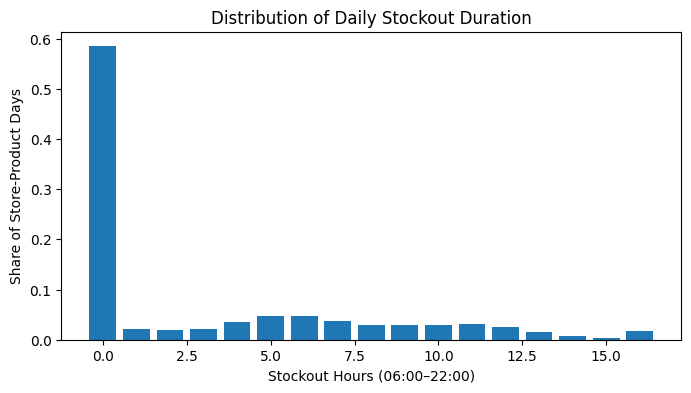

In [5]:
plt.figure(figsize=(8, 4))
plt.bar(
    stockout_distribution["stockout_hours"],
    stockout_distribution["share"]
)
plt.xlabel("Stockout Hours (06:00–22:00)")
plt.ylabel("Share of Store-Product Days")
plt.title("Distribution of Daily Stockout Duration")
plt.show()

### Hourly Data Consistency

In [6]:
study_train["hourly_sales_sum"] = study_train["hours_sale"].apply(
    lambda x: float(np.sum(x))
)

study_train["sales_sum_difference"] = (
    study_train["sale_amount"] - study_train["hourly_sales_sum"]
)

sales_consistency = pd.DataFrame({
    "max_abs_difference": [
        study_train["sales_sum_difference"].abs().max()
    ],
    "mean_abs_difference": [
        study_train["sales_sum_difference"].abs().mean()
    ],
    "n_nonclose": [
        (~np.isclose(
            study_train["sale_amount"],
            study_train["hourly_sales_sum"],
            atol=1e-8
        )).sum()
    ]
})

sales_consistency

,max_abs_difference,mean_abs_difference,n_nonclose
0,1.776357e-15,7.754288e-17,0


In [7]:
study_train["stockout_count_from_array"] = (
    study_train["hours_stock_status"]
    .apply(lambda x: int(np.sum(x[6:22])))
)

stockout_consistency = pd.DataFrame({
    "max_abs_difference": [
        (
            study_train["stock_hour6_22_cnt"]
            - study_train["stockout_count_from_array"]
        ).abs().max()
    ],
    "n_mismatches": [
        (
            study_train["stock_hour6_22_cnt"]
            != study_train["stockout_count_from_array"]
        ).sum()
    ]
})

stockout_consistency

,max_abs_difference,n_mismatches
0,0,0


In [8]:
study_train["weekday"] = study_train["dt"].dt.dayofweek

uncensored_baseline = (
    study_train[
        study_train["stock_hour6_22_cnt"] == 0
    ]
    .groupby(["product_id", "weekday"])["sale_amount"]
    .median()
    .rename("uncensored_weekday_median")
    .reset_index()
)

study_train = study_train.merge(
    uncensored_baseline,
    on=["product_id", "weekday"],
    how="left"
)

study_train["sales_relative_to_baseline"] = (
    study_train["sale_amount"]
    / study_train["uncensored_weekday_median"]
)

In [9]:
stockout_sales_relationship = (
    study_train
    .groupby("stock_hour6_22_cnt")
    .agg(
        n_days=("sale_amount", "size"),
        median_relative_sales=("sales_relative_to_baseline", "median"),
        mean_relative_sales=("sales_relative_to_baseline", "mean")
    )
    .reset_index()
)

stockout_sales_relationship

,stock_hour6_22_cnt,n_days,median_relative_sales,mean_relative_sales
0,0,9877,1.000000,1.100046
1,1,351,1.250000,1.347060
2,2,318,1.275253,1.342237
3,3,345,1.238095,1.370640
4,4,610,1.252907,1.408603
5,5,815,1.230769,1.316482
6,6,784,1.125000,1.234623
7,7,626,1.096006,1.204610
8,8,482,1.064583,1.193784
9,9,484,1.026481,1.131082


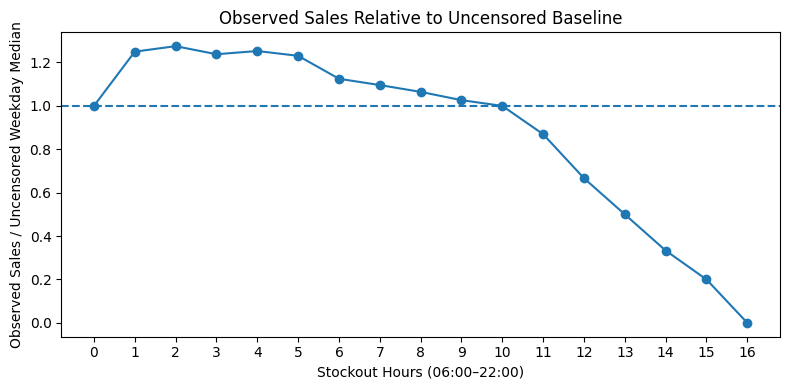

In [10]:
plt.figure(figsize=(8, 4))

plt.plot(
    stockout_sales_relationship["stock_hour6_22_cnt"],
    stockout_sales_relationship["median_relative_sales"],
    marker="o"
)

plt.axhline(1.0, linestyle="--")
plt.xticks(range(17))
plt.xlabel("Stockout Hours (06:00–22:00)")
plt.ylabel("Observed Sales / Uncensored Weekday Median")
plt.title("Observed Sales Relative to Uncensored Baseline")
plt.tight_layout()
plt.show()

### Censoring Pattern

Observed sales are elevated relative to the uncensored product-weekday baseline
when stockouts are short, consistent with stockouts occurring on relatively
high-demand days. As stockout duration increases, observed sales decline sharply,
indicating increasingly severe censoring of underlying demand. These patterns are
descriptive and are not interpreted causally.

### Sales Within Stockout-Labeled Hours

In [11]:
hourly_sales = np.vstack(study_train["hours_sale"].to_numpy())
hourly_stock = np.vstack(study_train["hours_stock_status"].to_numpy())

operating_sales = hourly_sales[:, 6:22]
operating_stock = hourly_stock[:, 6:22]

stockout_mask = operating_stock == 1
available_mask = operating_stock == 0

stockout_hour_summary = pd.DataFrame({
    "n_stockout_hours": [stockout_mask.sum()],
    "share_stockout_hours_with_positive_sales": [
        (operating_sales[stockout_mask] > 0).mean()
    ],
    "mean_sales_stockout_hour": [
        operating_sales[stockout_mask].mean()
    ],
    "median_sales_stockout_hour": [
        np.median(operating_sales[stockout_mask])
    ],
    "mean_sales_available_hour": [
        operating_sales[available_mask].mean()
    ],
    "median_sales_available_hour": [
        np.median(operating_sales[available_mask])
    ]
})

stockout_hour_summary

,n_stockout_hours,share_stockout_hours_with_positive_sales,mean_sales_stockout_hour,median_sales_stockout_hour,mean_sales_available_hour,median_sales_available_hour
0,52667,0.066076,0.012724,0.0,0.125276,0.1


## 4. Stockout-Aware Demand Recovery

In [12]:
hourly_rows = []

for row in study_train.itertuples(index=False):
    for hour in range(6, 22):
        hourly_rows.append({
            "product_id": row.product_id,
            "dt": row.dt,
            "weekday": row.weekday,
            "hour": hour,
            "hourly_sales": row.hours_sale[hour],
            "stockout_status": row.hours_stock_status[hour],
            "daily_stockout_hours": row.stock_hour6_22_cnt,
        })

hourly_panel = pd.DataFrame(hourly_rows)

hourly_panel.head()

,product_id,dt,weekday,hour,hourly_sales,stockout_status,daily_stockout_hours
0,59,2023-06-05,0,6,0.1,0,0
1,59,2023-06-05,0,7,0.4,0,0
2,59,2023-06-05,0,8,0.3,0,0
3,59,2023-06-05,0,9,0.1,0,0
4,59,2023-06-05,0,10,0.1,0,0


In [13]:
uncensored_hourly = hourly_panel[
    hourly_panel["daily_stockout_hours"] == 0
].copy()

hourly_profile = (
    uncensored_hourly
    .groupby(["product_id", "weekday", "hour"])["hourly_sales"]
    .median()
    .rename("baseline_hourly_sales")
    .reset_index()
)

hourly_profile.head()

,product_id,weekday,hour,baseline_hourly_sales
0,59,0,6,0.0
1,59,0,7,0.1
2,59,0,8,0.2
3,59,0,9,0.2
4,59,0,10,0.2


In [14]:
profile_coverage = (
    hourly_profile
    .groupby(["product_id", "weekday"])
    .agg(
        n_hours=("hour", "nunique"),
        total_baseline_sales=("baseline_hourly_sales", "sum")
    )
    .reset_index()
)

profile_coverage.describe()

,product_id,weekday,n_hours,total_baseline_sales
count,175.000000,175.000000,175.0,175.000000
mean,279.440000,3.000000,16.0,1.113771
std,149.163898,2.005739,0.0,0.778566
min,59.000000,0.000000,16.0,0.000000
25%,160.000000,1.000000,16.0,0.500000
50%,266.000000,3.000000,16.0,1.100000
75%,415.000000,5.000000,16.0,1.575000
max,554.000000,6.000000,16.0,3.960000


In [15]:
(profile_coverage["total_baseline_sales"] <= 0).sum()

np.int64(10)

In [16]:
recovery_panel = hourly_panel.merge(
    hourly_profile,
    on=["product_id", "weekday", "hour"],
    how="left"
)

valid_scale = (
    (recovery_panel["stockout_status"] == 0) &
    (recovery_panel["baseline_hourly_sales"] > 0)
)

scale_estimates = (
    recovery_panel[valid_scale]
    .assign(
        hourly_ratio=lambda x:
            x["hourly_sales"] / x["baseline_hourly_sales"]
    )
    .groupby(["product_id", "dt"])["hourly_ratio"]
    .median()
    .rename("daily_intensity")
    .reset_index()
)

scale_estimates["daily_intensity"].describe()

count    15362.000000
mean         1.206992
std          0.882088
min          0.000000
25%          0.919643
50%          1.000000
75%          1.500000
max          9.000000
Name: daily_intensity, dtype: float64

### Recovery Diagnostics

In [17]:
zero_baseline_profiles = (
    profile_coverage[
        profile_coverage["total_baseline_sales"] <= 0
    ]
    .sort_values(["product_id", "weekday"])
)

zero_baseline_profiles

,product_id,weekday,n_hours,total_baseline_sales
84,266,0,16,0.0
85,266,1,16,0.0
86,266,2,16,0.0
87,266,3,16,0.0
88,266,4,16,0.0
89,266,5,16,0.0
90,266,6,16,0.0
119,380,0,16,0.0
142,453,2,16,0.0
144,453,4,16,0.0


In [18]:
uncensored_support = (
    study_train[
        study_train["stock_hour6_22_cnt"] == 0
    ]
    .groupby(["product_id", "weekday"])
    .size()
    .rename("n_uncensored_days")
    .reset_index()
)

zero_baseline_support = zero_baseline_profiles.merge(
    uncensored_support,
    on=["product_id", "weekday"],
    how="left"
)

zero_baseline_support

,product_id,weekday,n_hours,total_baseline_sales,n_uncensored_days
0,266,0,16,0.0,62
1,266,1,16,0.0,58
2,266,2,16,0.0,68
3,266,3,16,0.0,67
4,266,4,16,0.0,51
5,266,5,16,0.0,50
6,266,6,16,0.0,71
7,380,0,16,0.0,48
8,453,2,16,0.0,53
9,453,4,16,0.0,84


In [19]:
valid_scale_hours = (
    recovery_panel[valid_scale]
    .groupby(["product_id", "dt"])
    .size()
    .rename("n_valid_scale_hours")
    .reset_index()
)

intensity_diagnostics = (
    study_train[
        ["product_id", "dt", "stock_hour6_22_cnt", "sale_amount"]
    ]
    .merge(
        valid_scale_hours,
        on=["product_id", "dt"],
        how="left"
    )
    .merge(
        scale_estimates,
        on=["product_id", "dt"],
        how="left"
    )
)

intensity_diagnostics["n_valid_scale_hours"] = (
    intensity_diagnostics["n_valid_scale_hours"].fillna(0).astype(int)
)

intensity_diagnostics["intensity_missing"] = (
    intensity_diagnostics["daily_intensity"].isna()
)

intensity_diagnostics[
    [
        "n_valid_scale_hours",
        "daily_intensity"
    ]
].describe()

,n_valid_scale_hours,daily_intensity
count,16904.000000,15362.000000
mean,7.261536,1.206992
std,4.279826,0.882088
min,0.000000,0.000000
25%,4.000000,0.919643
50%,8.000000,1.000000
75%,11.000000,1.500000
max,16.000000,9.000000


In [20]:
missing_by_stockout = (
    intensity_diagnostics
    .groupby("stock_hour6_22_cnt")
    .agg(
        n_days=("product_id", "size"),
        n_missing=("intensity_missing", "sum"),
        median_valid_hours=("n_valid_scale_hours", "median")
    )
    .reset_index()
)

missing_by_stockout["missing_share"] = (
    missing_by_stockout["n_missing"]
    / missing_by_stockout["n_days"]
)

missing_by_stockout

,stock_hour6_22_cnt,n_days,n_missing,median_valid_hours,missing_share
0,0,9877,612,10.0,0.061962
1,1,351,39,9.0,0.111111
2,2,318,13,10.0,0.040881
3,3,345,19,10.0,0.055072
4,4,610,42,9.0,0.068852
5,5,815,48,9.0,0.058896
6,6,784,62,7.0,0.079082
7,7,626,60,6.0,0.095847
8,8,482,43,5.0,0.089212
9,9,484,49,5.0,0.101240


The initial recovery specification used product-weekday-hour median sales as
the uncensored hourly baseline. Diagnostics showed that this approach was
unstable for sparse products: 10 product-weekday profiles had zero total
baseline sales despite having substantial numbers of uncensored training days.
The recovery method was therefore revised to use aggregated hourly demand
shares estimated from uncensored days.

### Revised Hourly-Share Recovery

In [21]:
uncensored_operating = hourly_panel[
    hourly_panel["daily_stockout_hours"] == 0
].copy()

hourly_share_profile = (
    uncensored_operating
    .groupby(["product_id", "weekday", "hour"], as_index=False)
    .agg(total_hourly_sales=("hourly_sales", "sum"))
)

profile_totals = (
    hourly_share_profile
    .groupby(["product_id", "weekday"])["total_hourly_sales"]
    .transform("sum")
)

hourly_share_profile["hourly_share"] = (
    hourly_share_profile["total_hourly_sales"]
    / profile_totals
)

hourly_share_profile.head()

,product_id,weekday,hour,total_hourly_sales,hourly_share
0,59,0,6,6.4,0.044181
1,59,0,7,11.0,0.075935
2,59,0,8,14.9,0.102858
3,59,0,9,16.2,0.111832
4,59,0,10,13.2,0.091122


In [22]:
share_profile_check = (
    hourly_share_profile
    .groupby(["product_id", "weekday"])
    .agg(
        n_hours=("hour", "nunique"),
        share_sum=("hourly_share", "sum"),
        total_sales=("total_hourly_sales", "sum")
    )
    .reset_index()
)

share_profile_check.describe()

,product_id,weekday,n_hours,share_sum,total_sales
count,175.000000,175.000000,175.0,1.750000e+02,175.000000
mean,279.440000,3.000000,16.0,1.000000e+00,95.422137
std,149.163898,2.005739,0.0,4.686153e-17,63.048486
min,59.000000,0.000000,16.0,1.000000e+00,9.700000
25%,160.000000,1.000000,16.0,1.000000e+00,47.557500
50%,266.000000,3.000000,16.0,1.000000e+00,80.700000
75%,415.000000,5.000000,16.0,1.000000e+00,126.735000
max,554.000000,6.000000,16.0,1.000000e+00,352.522000


In [23]:
share_profile_check[
    share_profile_check["total_sales"] <= 0
]

,product_id,weekday,n_hours,share_sum,total_sales


In [24]:
np.abs(
    share_profile_check["share_sum"] - 1
).describe()

count    1.750000e+02
mean     1.839798e-17
std      4.307635e-17
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.220446e-16
Name: share_sum, dtype: float64

## 5. Pseudo-Censoring Validation

In [25]:
VALIDATION_END = study_train["dt"].max()
VALIDATION_START = VALIDATION_END - pd.Timedelta(days=55)

development_train = study_train[
    study_train["dt"] < VALIDATION_START
].copy()

validation_train = study_train[
    study_train["dt"] >= VALIDATION_START
].copy()

print(
    "Development:",
    development_train["dt"].min().date(),
    "to",
    development_train["dt"].max().date()
)

print(
    "Validation:",
    validation_train["dt"].min().date(),
    "to",
    validation_train["dt"].max().date()
)

print("Development rows:", len(development_train))
print("Validation rows:", len(validation_train))

Development: 2023-06-05 to 2025-05-18
Validation: 2025-05-19 to 2025-07-13
Development rows: 15504
Validation rows: 1400


In [26]:
validation_uncensored = validation_train[
    validation_train["stock_hour6_22_cnt"] == 0
].copy()

print(
    f"Uncensored validation days: "
    f"{len(validation_uncensored):,}"
)

print(
    f"Products represented: "
    f"{validation_uncensored['product_id'].nunique()}"
)

Uncensored validation days: 669
Products represented: 25


In [27]:
def build_hourly_share_profile(df):
    rows = []

    for row in df.itertuples(index=False):
        if row.stock_hour6_22_cnt != 0:
            continue

        weekday = row.dt.dayofweek

        for hour in range(6, 22):
            rows.append({
                "product_id": row.product_id,
                "weekday": weekday,
                "hour": hour,
                "hourly_sales": row.hours_sale[hour],
            })

    hourly = pd.DataFrame(rows)

    profile = (
        hourly
        .groupby(
            ["product_id", "weekday", "hour"],
            as_index=False
        )
        .agg(
            total_hourly_sales=("hourly_sales", "sum")
        )
    )

    totals = (
        profile
        .groupby(
            ["product_id", "weekday"]
        )["total_hourly_sales"]
        .transform("sum")
    )

    profile["hourly_share"] = (
        profile["total_hourly_sales"] / totals
    )

    return profile

In [28]:
development_profile = build_hourly_share_profile(
    development_train
)

development_profile.head()

,product_id,weekday,hour,total_hourly_sales,hourly_share
0,59,0,6,6.4,0.044181
1,59,0,7,11.0,0.075935
2,59,0,8,14.9,0.102858
3,59,0,9,16.2,0.111832
4,59,0,10,13.2,0.091122


In [29]:
development_profile_check = (
    development_profile
    .groupby(["product_id", "weekday"])
    .agg(
        n_hours=("hour", "nunique"),
        share_sum=("hourly_share", "sum"),
        total_sales=("total_hourly_sales", "sum")
    )
    .reset_index()
)

print(
    "Number of profiles:",
    len(development_profile_check)
)

print(
    "Incomplete profiles:",
    (
        development_profile_check["n_hours"] != 16
    ).sum()
)

print(
    "Zero-sales profiles:",
    (
        development_profile_check["total_sales"] <= 0
    ).sum()
)

development_profile_check["total_sales"].describe()

Number of profiles: 175
Incomplete profiles: 0
Zero-sales profiles: 0


count    175.000000
mean      88.329023
std       60.887456
min        7.800000
25%       43.775000
50%       76.300000
75%      116.835000
max      344.478000
Name: total_sales, dtype: float64

### Realistic Stockout Masks

In [30]:
mask_records = []

for row in development_train.itertuples(index=False):
    mask = (
        np.asarray(row.hours_stock_status)[6:22]
        .astype(bool)
    )

    n_masked = int(mask.sum())

    if 1 <= n_masked <= 15:
        mask_records.append({
            "product_id": int(row.product_id),
            "weekday": int(row.dt.dayofweek),
            "mask": mask,
            "n_masked": n_masked,
        })

mask_pool = pd.DataFrame(mask_records)

print(f"Development stockout masks: {len(mask_pool):,}")

mask_pool["n_masked"].describe()

Development stockout masks: 6,054


count    6054.000000
mean        7.174926
std         3.507415
min         1.000000
25%         5.000000
50%         7.000000
75%        10.000000
max        15.000000
Name: n_masked, dtype: float64

In [31]:
mask_support = (
    mask_pool
    .groupby(["product_id", "weekday"])
    .size()
    .rename("n_masks")
    .reset_index()
)

all_profile_keys = pd.MultiIndex.from_product(
    [PRODUCT_IDS, range(7)],
    names=["product_id", "weekday"]
).to_frame(index=False)

mask_support_full = (
    all_profile_keys
    .merge(
        mask_support,
        on=["product_id", "weekday"],
        how="left"
    )
)

mask_support_full["n_masks"] = (
    mask_support_full["n_masks"]
    .fillna(0)
    .astype(int)
)

mask_support_full["n_masks"].describe()

count    175.000000
mean      34.594286
std       15.634877
min        6.000000
25%       24.000000
50%       31.000000
75%       43.000000
max       80.000000
Name: n_masks, dtype: float64

In [32]:
mask_support_full[
    mask_support_full["n_masks"] == 0
]

,product_id,weekday,n_masks


### Pseudo-Censoring Simulation

In [33]:
profile_lookup = {
    (int(product_id), int(weekday)):
        group.sort_values("hour")["hourly_share"].to_numpy(dtype=float)

    for (product_id, weekday), group
    in development_profile.groupby(["product_id", "weekday"])
}

exact_mask_lookup = {
    (int(product_id), int(weekday)):
        group["mask"].tolist()

    for (product_id, weekday), group
    in mask_pool.groupby(["product_id", "weekday"])
}

product_mask_lookup = {
    int(product_id):
        group["mask"].tolist()

    for product_id, group
    in mask_pool.groupby("product_id")
}

In [34]:
rng = np.random.default_rng(432)

N_MASKS_PER_DAY = 5
pseudo_records = []

for row in validation_uncensored.itertuples(index=False):

    product_id = int(row.product_id)
    weekday = int(row.dt.dayofweek)

    hourly_sales = np.asarray(
        row.hours_sale,
        dtype=float
    )[6:22]

    true_operating_sales = float(hourly_sales.sum())

    hourly_shares = profile_lookup[
        (product_id, weekday)
    ]

    masks = exact_mask_lookup.get(
        (product_id, weekday),
        []
    )

    mask_source = "product_weekday"

    if len(masks) == 0:
        masks = product_mask_lookup.get(
            product_id,
            []
        )
        mask_source = "product"

    if len(masks) == 0:
        continue

    selected_indices = rng.choice(
        len(masks),
        size=N_MASKS_PER_DAY,
        replace=(len(masks) < N_MASKS_PER_DAY)
    )

    for idx in selected_indices:

        mask = np.asarray(
            masks[idx],
            dtype=bool
        )

        available = ~mask

        n_masked = int(mask.sum())
        n_available = int(available.sum())

        available_sales = float(
            hourly_sales[available].sum()
        )

        available_profile_share = float(
            hourly_shares[available].sum()
        )

        naive_estimate = available_sales

        uniform_estimate = (
            available_sales
            * 16
            / n_available
        )

        profile_estimate = (
            available_sales
            / available_profile_share
            if available_profile_share > 1e-12
            else np.nan
        )

        pseudo_records.append({
            "product_id": product_id,
            "dt": row.dt,
            "weekday": weekday,
            "mask_source": mask_source,
            "n_masked": n_masked,
            "n_available": n_available,
            "true_operating_sales": true_operating_sales,
            "available_sales": available_sales,
            "available_profile_share":
                available_profile_share,
            "naive_estimate": naive_estimate,
            "uniform_estimate": uniform_estimate,
            "profile_estimate": profile_estimate,
        })

pseudo_results = pd.DataFrame(
    pseudo_records
)

print(
    f"Pseudo-censored cases: "
    f"{len(pseudo_results):,}"
)

pseudo_results.head()

Pseudo-censored cases: 3,345


,product_id,dt,weekday,mask_source,n_masked,n_available,true_operating_sales,available_sales,available_profile_share,naive_estimate,uniform_estimate,profile_estimate
0,59,2025-05-20,1,product_weekday,1,15,3.7,3.7,0.984595,3.7,3.946667,3.757891
1,59,2025-05-20,1,product_weekday,15,1,3.7,0.5,0.048225,0.5,8.000000,10.368056
2,59,2025-05-20,1,product_weekday,12,4,3.7,1.1,0.352311,1.1,4.400000,3.122243
3,59,2025-05-20,1,product_weekday,6,10,3.7,2.8,0.777629,2.8,4.480000,3.600689
4,59,2025-05-20,1,product_weekday,10,6,3.7,1.7,0.521768,1.7,4.533333,3.258151


In [35]:
pseudo_results[
    [
        "n_masked",
        "n_available",
        "available_profile_share",
        "true_operating_sales",
        "available_sales",
        "profile_estimate",
    ]
].describe()

,n_masked,n_available,available_profile_share,true_operating_sales,available_sales,profile_estimate
count,3345.000000,3345.000000,3345.000000,3345.000000,3345.000000,3345.000000
mean,6.851420,9.148580,0.693420,1.855448,1.306143,1.858287
std,3.395358,3.395358,0.223126,0.997543,0.896804,1.115084
min,1.000000,1.000000,0.021701,0.200000,0.000000,0.000000
25%,4.000000,6.000000,0.542793,1.100000,0.700000,1.080875
50%,6.000000,10.000000,0.729927,1.600000,1.100000,1.645631
75%,10.000000,12.000000,0.883426,2.400000,1.800000,2.416766
max,15.000000,15.000000,1.000000,5.999000,5.599000,10.368056


In [36]:
print(
    "Invalid profile estimates:",
    pseudo_results["profile_estimate"].isna().sum()
)

print(
    "Minimum available profile share:",
    pseudo_results["available_profile_share"].min()
)

Invalid profile estimates: 0
Minimum available profile share: 0.021701388888888888


In [37]:
pseudo_denominator_check = (
    pseudo_results
    .groupby("n_masked")
    .agg(
        n_cases=("product_id", "size"),
        median_available_share=(
            "available_profile_share",
            "median"
        ),
        min_available_share=(
            "available_profile_share",
            "min"
        ),
        n_invalid=(
            "profile_estimate",
            lambda x: x.isna().sum()
        )
    )
    .reset_index()
)

pseudo_denominator_check

,n_masked,n_cases,median_available_share,min_available_share,n_invalid
0,1,191,0.980140,0.807692,0
1,2,155,0.958918,0.714286,0
2,3,201,0.930686,0.716637,0
3,4,317,0.905052,0.563738,0
4,5,454,0.855464,0.463696,0
5,6,400,0.777629,0.448190,0
6,7,311,0.693056,0.340965,0
7,8,230,0.641744,0.336968,0
8,9,244,0.582370,0.272160,0
9,10,243,0.534743,0.268786,0


### Recovery Performance

In [38]:
methods = {
    "Naive": "naive_estimate",
    "Uniform": "uniform_estimate",
    "Hourly Share": "profile_estimate",
}

metric_rows = []

for method, column in methods.items():
    valid = pseudo_results[
        pseudo_results[column].notna()
    ].copy()

    error = (
        valid[column]
        - valid["true_operating_sales"]
    )

    absolute_error = error.abs()

    metric_rows.append({
        "method": method,
        "n_cases": len(valid),
        "mae": absolute_error.mean(),
        "median_ae": absolute_error.median(),
        "bias": error.mean(),
        "wape": (
            absolute_error.sum()
            / valid["true_operating_sales"].sum()
        ),
    })

recovery_metrics = pd.DataFrame(metric_rows)

recovery_metrics

,method,n_cases,mae,median_ae,bias,wape
0,Naive,3345,0.549306,0.400000,-0.549306,0.296050
1,Uniform,3345,0.565855,0.400000,0.441766,0.304969
2,Hourly Share,3345,0.279259,0.170624,0.002839,0.150508


In [39]:
pseudo_results["severity"] = pd.cut(
    pseudo_results["n_masked"],
    bins=[0, 4, 8, 12, 15],
    labels=["1-4", "5-8", "9-12", "13-15"]
)

severity_rows = []

for severity, group in pseudo_results.groupby(
    "severity",
    observed=True
):
    for method, column in methods.items():
        valid = group[
            group[column].notna()
        ].copy()

        error = (
            valid[column]
            - valid["true_operating_sales"]
        )

        absolute_error = error.abs()

        severity_rows.append({
            "severity": severity,
            "method": method,
            "n_cases": len(valid),
            "mae": absolute_error.mean(),
            "bias": error.mean(),
            "wape": (
                absolute_error.sum()
                / valid["true_operating_sales"].sum()
            ),
        })

severity_metrics = pd.DataFrame(
    severity_rows
)

severity_metrics

,severity,method,n_cases,mae,bias,wape
0,1-4,Naive,864,0.154020,-0.154020,0.077660
1,1-4,Uniform,864,0.273299,0.231007,0.137802
2,1-4,Hourly Share,864,0.102700,0.004167,0.051783
3,5-8,Naive,1395,0.463302,-0.463302,0.250374
4,5-8,Uniform,1395,0.507104,0.416880,0.274045
5,5-8,Hourly Share,1395,0.223063,-0.007559,0.120546
6,9-12,Naive,912,0.896522,-0.896522,0.504320
7,9-12,Uniform,912,0.864186,0.731531,0.486130
8,9-12,Hourly Share,912,0.398730,-0.004627,0.224297
9,13-15,Naive,174,1.381724,-1.381724,0.828121


In [40]:
comparison = (
    severity_metrics
    .pivot(
        index="severity",
        columns="method",
        values="wape"
    )
    .reset_index()
)

comparison["hourly_share_vs_uniform"] = (
    (
        comparison["Uniform"]
        - comparison["Hourly Share"]
    )
    / comparison["Uniform"]
)

comparison

method,severity,Hourly Share,Naive,Uniform,hourly_share_vs_uniform
0,1-4,0.051783,0.077660,0.137802,0.624222
1,13-15,0.587542,0.828121,0.554928,-0.058771
2,5-8,0.120546,0.250374,0.274045,0.560124
3,9-12,0.224297,0.504320,0.486130,0.538606


### Historical Fallback for Severe Censoring

In [41]:
development_uncensored_daily = development_train[
    development_train["stock_hour6_22_cnt"] == 0
].copy()

development_uncensored_daily["weekday"] = (
    development_uncensored_daily["dt"].dt.dayofweek
)

development_uncensored_daily["operating_sales"] = (
    development_uncensored_daily["hours_sale"].apply(
        lambda x: float(
            np.sum(np.asarray(x, dtype=float)[6:22])
        )
    )
)

historical_fallback = (
    development_uncensored_daily
    .groupby(
        ["product_id", "weekday"],
        as_index=False
    )
    .agg(
        historical_estimate=("operating_sales", "mean")
    )
)

historical_fallback.describe()

,product_id,weekday,historical_estimate
count,175.000000,175.000000,175.000000
mean,279.440000,3.000000,1.628089
std,149.163898,2.005739,0.851593
min,59.000000,0.000000,0.306190
25%,160.000000,1.000000,0.986791
50%,266.000000,3.000000,1.536724
75%,415.000000,5.000000,2.168771
max,554.000000,6.000000,4.992435


In [42]:
print(
    "Profiles:",
    len(historical_fallback)
)

print(
    "Zero estimates:",
    (
        historical_fallback["historical_estimate"] <= 0
    ).sum()
)

Profiles: 175
Zero estimates: 0


In [43]:
pseudo_with_history = pseudo_results.merge(
    historical_fallback,
    on=["product_id", "weekday"],
    how="left"
)

historical_rows = []

for severity, group in pseudo_with_history.groupby(
    "severity",
    observed=True
):
    error = (
        group["historical_estimate"]
        - group["true_operating_sales"]
    )

    absolute_error = error.abs()

    historical_rows.append({
        "severity": severity,
        "method": "Historical",
        "n_cases": len(group),
        "mae": absolute_error.mean(),
        "bias": error.mean(),
        "wape": (
            absolute_error.sum()
            / group["true_operating_sales"].sum()
        ),
    })

historical_metrics = pd.DataFrame(
    historical_rows
)

historical_metrics

,severity,method,n_cases,mae,bias,wape
0,1-4,Historical,864,0.618751,-0.279238,0.311986
1,5-8,Historical,1395,0.587631,-0.311552,0.317563
2,9-12,Historical,912,0.576850,-0.353703,0.324495
3,13-15,Historical,174,0.529564,-0.220355,0.317388


In [44]:
historical_fallback_compare = (
    development_uncensored_daily
    .groupby(
        ["product_id", "weekday"],
        as_index=False
    )
    .agg(
        historical_mean=("operating_sales", "mean"),
        historical_median=("operating_sales", "median")
    )
)

pseudo_history_compare = pseudo_results.merge(
    historical_fallback_compare,
    on=["product_id", "weekday"],
    how="left"
)

severe_cases = pseudo_history_compare[
    pseudo_history_compare["n_masked"] >= 13
].copy()

history_comparison_rows = []

for method, column in {
    "Mean": "historical_mean",
    "Median": "historical_median",
}.items():

    error = (
        severe_cases[column]
        - severe_cases["true_operating_sales"]
    )

    absolute_error = error.abs()

    history_comparison_rows.append({
        "method": method,
        "n_cases": len(severe_cases),
        "mae": absolute_error.mean(),
        "median_ae": absolute_error.median(),
        "bias": error.mean(),
        "wape": (
            absolute_error.sum()
            / severe_cases["true_operating_sales"].sum()
        ),
    })

historical_fallback_comparison = pd.DataFrame(
    history_comparison_rows
)

historical_fallback_comparison

,method,n_cases,mae,median_ae,bias,wape
0,Mean,174,0.529564,0.415332,-0.220355,0.317388
1,Median,174,0.555805,0.400000,-0.338793,0.333115


In [45]:
hybrid_results = pseudo_with_history.copy()

hybrid_results["hybrid_estimate"] = np.where(
    hybrid_results["n_masked"] <= 12,
    hybrid_results["profile_estimate"],
    hybrid_results["historical_estimate"]
)

hybrid_error = (
    hybrid_results["hybrid_estimate"]
    - hybrid_results["true_operating_sales"]
)

hybrid_absolute_error = hybrid_error.abs()

hybrid_metrics = pd.DataFrame({
    "n_cases": [len(hybrid_results)],
    "mae": [hybrid_absolute_error.mean()],
    "median_ae": [hybrid_absolute_error.median()],
    "bias": [hybrid_error.mean()],
    "wape": [
        hybrid_absolute_error.sum()
        / hybrid_results["true_operating_sales"].sum()
    ],
})

hybrid_metrics

,n_cases,mae,median_ae,bias,wape
0,3345,0.255812,0.169503,-0.0148,0.137871


## 6. Final Hybrid Demand Recovery

The recovery rule is fixed based on the internal pseudo-censoring validation. Observed sales are retained on uncensored days, hourly-share recovery is used when 1–12 operating hours are stockout-labeled, and a product-weekday historical mean is used under severe censoring. Recovered demand is constrained to be no lower than observed sales.

In [46]:
final_hybrid_results = pseudo_with_history.copy()

final_hybrid_results["hybrid_estimate"] = np.where(
    final_hybrid_results["n_masked"] <= 12,
    np.maximum(
        final_hybrid_results["profile_estimate"],
        final_hybrid_results["available_sales"]
    ),
    np.maximum(
        final_hybrid_results["historical_estimate"],
        final_hybrid_results["available_sales"]
    )
)

final_hybrid_error = (
    final_hybrid_results["hybrid_estimate"]
    - final_hybrid_results["true_operating_sales"]
)

final_hybrid_absolute_error = final_hybrid_error.abs()

final_hybrid_metrics = pd.DataFrame({
    "n_cases": [len(final_hybrid_results)],
    "mae": [final_hybrid_absolute_error.mean()],
    "median_ae": [final_hybrid_absolute_error.median()],
    "bias": [final_hybrid_error.mean()],
    "wape": [
        final_hybrid_absolute_error.sum()
        / final_hybrid_results["true_operating_sales"].sum()
    ],
})

final_hybrid_metrics

,n_cases,mae,median_ae,bias,wape
0,3345,0.255777,0.169503,-0.014765,0.137852


In [47]:
final_uncensored_operating = hourly_panel[
    hourly_panel["daily_stockout_hours"] == 0
].copy()

final_hourly_profile = (
    final_uncensored_operating
    .groupby(
        ["product_id", "weekday", "hour"],
        as_index=False
    )
    .agg(
        total_hourly_sales=("hourly_sales", "sum")
    )
)

final_profile_totals = (
    final_hourly_profile
    .groupby(
        ["product_id", "weekday"]
    )["total_hourly_sales"]
    .transform("sum")
)

final_hourly_profile["hourly_share"] = (
    final_hourly_profile["total_hourly_sales"]
    / final_profile_totals
)

final_hourly_profile.head()

,product_id,weekday,hour,total_hourly_sales,hourly_share
0,59,0,6,6.4,0.044181
1,59,0,7,11.0,0.075935
2,59,0,8,14.9,0.102858
3,59,0,9,16.2,0.111832
4,59,0,10,13.2,0.091122


In [48]:
final_uncensored_daily = study_train[
    study_train["stock_hour6_22_cnt"] == 0
].copy()

final_uncensored_daily["weekday"] = (
    final_uncensored_daily["dt"].dt.dayofweek
)

final_uncensored_daily["operating_sales"] = (
    final_uncensored_daily["hours_sale"].apply(
        lambda x: float(
            np.sum(np.asarray(x, dtype=float)[6:22])
        )
    )
)

final_historical_fallback = (
    final_uncensored_daily
    .groupby(
        ["product_id", "weekday"],
        as_index=False
    )
    .agg(
        historical_mean=("operating_sales", "mean")
    )
)

final_historical_fallback.head()

,product_id,weekday,historical_mean
0,59,0,2.374754
1,59,1,2.559677
2,59,2,2.378571
3,59,3,2.330000
4,59,4,2.436986


In [49]:
final_profile_check = (
    final_hourly_profile
    .groupby(["product_id", "weekday"])
    .agg(
        n_hours=("hour", "nunique"),
        share_sum=("hourly_share", "sum"),
        total_sales=("total_hourly_sales", "sum")
    )
    .reset_index()
)

print("Hourly profiles:", len(final_profile_check))
print(
    "Incomplete profiles:",
    (final_profile_check["n_hours"] != 16).sum()
)
print(
    "Zero-sales profiles:",
    (final_profile_check["total_sales"] <= 0).sum()
)
print(
    "Historical profiles:",
    len(final_historical_fallback)
)
print(
    "Zero historical means:",
    (final_historical_fallback["historical_mean"] <= 0).sum()
)

Hourly profiles: 175
Incomplete profiles: 0
Zero-sales profiles: 0
Historical profiles: 175
Zero historical means: 0


In [50]:
final_share_lookup = {
    (int(product_id), int(weekday)):
        group.sort_values("hour")["hourly_share"].to_numpy(dtype=float)

    for (product_id, weekday), group
    in final_hourly_profile.groupby(["product_id", "weekday"])
}

final_history_lookup = {
    (int(row.product_id), int(row.weekday)):
        float(row.historical_mean)

    for row in final_historical_fallback.itertuples(index=False)
}

In [51]:
recovered_records = []

for row in study_train.itertuples(index=False):

    product_id = int(row.product_id)
    weekday = int(row.dt.dayofweek)

    sales = np.asarray(
        row.hours_sale,
        dtype=float
    )

    stock = np.asarray(
        row.hours_stock_status,
        dtype=int
    )

    operating_sales = sales[6:22]
    operating_stock = stock[6:22]

    outside_sales = float(
        sales[:6].sum() + sales[22:].sum()
    )

    observed_operating = float(
        operating_sales.sum()
    )

    stockout_hours = int(
        operating_stock.sum()
    )

    if stockout_hours == 0:
        recovered_operating = observed_operating
        recovery_method = "observed"

    elif stockout_hours <= 12:
        shares = final_share_lookup[
            (product_id, weekday)
        ]

        available = operating_stock == 0

        available_sales = float(
            operating_sales[available].sum()
        )

        available_share = float(
            shares[available].sum()
        )

        if available_share > 1e-12:
            profile_estimate = (
                available_sales / available_share
            )

            recovered_operating = max(
                observed_operating,
                profile_estimate
            )

            recovery_method = "hourly_share"

        else:
            recovered_operating = max(
                observed_operating,
                final_history_lookup[
                    (product_id, weekday)
                ]
            )

            recovery_method = "historical_mean"

    else:
        recovered_operating = max(
            observed_operating,
            final_history_lookup[
                (product_id, weekday)
            ]
        )

        recovery_method = "historical_mean"

    recovered_demand = (
        outside_sales + recovered_operating
    )

    recovered_records.append({
        "product_id": product_id,
        "dt": row.dt,
        "observed_sales": float(row.sale_amount),
        "stockout_hours": stockout_hours,
        "recovery_method": recovery_method,
        "recovered_demand": recovered_demand,
    })

recovered_demand = pd.DataFrame(
    recovered_records
)

recovered_demand.head()

,product_id,dt,observed_sales,stockout_hours,recovery_method,recovered_demand
0,59,2023-06-05,2.8,0,observed,2.800000
1,59,2023-06-06,3.7,0,observed,3.700000
2,59,2023-06-07,3.2,0,observed,3.200000
3,59,2023-06-08,0.3,13,historical_mean,2.330000
4,59,2023-06-09,2.7,5,hourly_share,3.121053


### Recovery Integrity Checks

In [52]:
recovery_check = pd.DataFrame({
    "n_rows": [len(recovered_demand)],
    "n_products": [
        recovered_demand["product_id"].nunique()
    ],
    "missing_recovered": [
        recovered_demand["recovered_demand"].isna().sum()
    ],
    "below_observed": [
        (
            recovered_demand["recovered_demand"]
            < recovered_demand["observed_sales"] - 1e-10
        ).sum()
    ],
    "negative_recovered": [
        (
            recovered_demand["recovered_demand"] < 0
        ).sum()
    ],
})

recovery_check

,n_rows,n_products,missing_recovered,below_observed,negative_recovered
0,16904,25,0,0,0


In [53]:
uncensored_check = recovered_demand[
    recovered_demand["stockout_hours"] == 0
].copy()

np.abs(
    uncensored_check["recovered_demand"]
    - uncensored_check["observed_sales"]
).describe()

count    9.877000e+03
mean     1.084370e-16
std      1.911343e-16
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      2.220446e-16
max      3.552714e-15
dtype: float64

In [54]:
method_usage = (
    recovered_demand["recovery_method"]
    .value_counts()
    .rename_axis("recovery_method")
    .reset_index(name="n_days")
)

method_usage["share"] = (
    method_usage["n_days"]
    / len(recovered_demand)
)

method_usage

,recovery_method,n_days,share
0,observed,9877,0.584300
1,hourly_share,6288,0.371983
2,historical_mean,739,0.043717


In [55]:
recovered_demand["recovery_uplift"] = (
    recovered_demand["recovered_demand"]
    - recovered_demand["observed_sales"]
)

recovered_demand["uplift_ratio"] = np.where(
    recovered_demand["observed_sales"] > 0,
    recovered_demand["recovery_uplift"]
    / recovered_demand["observed_sales"],
    np.nan
)

In [56]:
uplift_summary = (
    recovered_demand
    .groupby("recovery_method")
    .agg(
        n_days=("product_id", "size"),
        mean_observed=("observed_sales", "mean"),
        mean_recovered=("recovered_demand", "mean"),
        mean_uplift=("recovery_uplift", "mean"),
        median_uplift=("recovery_uplift", "median"),
        max_uplift=("recovery_uplift", "max"),
    )
    .reset_index()
)

uplift_summary

,recovery_method,n_days,mean_observed,mean_recovered,mean_uplift,median_uplift,max_uplift
0,historical_mean,739,0.529348,1.783076,1.253728e+00,0.917797,4.992543e+00
1,hourly_share,6288,1.821888,2.458841,6.369535e-01,0.396957,1.023087e+01
2,observed,9877,1.785367,1.785367,6.706637e-17,0.000000,3.552714e-15


In [57]:
stockout_recovery_summary = (
    recovered_demand
    .groupby("stockout_hours")
    .agg(
        n_days=("product_id", "size"),
        mean_observed=("observed_sales", "mean"),
        mean_recovered=("recovered_demand", "mean"),
        mean_uplift=("recovery_uplift", "mean"),
        median_uplift=("recovery_uplift", "median"),
    )
    .reset_index()
)

stockout_recovery_summary

,stockout_hours,n_days,mean_observed,mean_recovered,mean_uplift,median_uplift
0,0,9877,1.785367,1.785367,6.706637e-17,0.000000
1,1,351,2.281430,2.330783,4.935296e-02,0.028008
2,2,318,2.421447,2.527193,1.057468e-01,0.070117
3,3,345,2.360548,2.545747,1.851995e-01,0.125553
4,4,610,2.130770,2.345730,2.149595e-01,0.151382
5,5,815,1.986129,2.295186,3.090569e-01,0.240240
6,6,784,1.830102,2.297622,4.675200e-01,0.366160
7,7,626,1.805070,2.491067,6.859964e-01,0.534083
8,8,482,1.696266,2.514143,8.178773e-01,0.657071
9,9,484,1.686157,2.649609,9.634518e-01,0.799241


In [58]:
recovered_demand.sort_values(
    "recovery_uplift",
    ascending=False
).head(20)

,product_id,dt,observed_sales,stockout_hours,recovery_method,recovered_demand,recovery_uplift,uplift_ratio
748,99,2023-06-20,7.8,11,hourly_share,18.030866,10.230866,1.311649
746,99,2023-06-18,6.5,11,hourly_share,13.797207,7.297207,1.122647
1109,99,2024-06-15,2.4,11,hourly_share,9.227142,6.827142,2.844642
770,99,2023-07-12,5.5,10,hourly_share,12.286761,6.786761,1.233957
15015,503,2024-06-07,4.6,12,hourly_share,11.149779,6.549779,1.423865
362,59,2024-07-08,3.2,12,hourly_share,9.259093,6.059093,1.893466
784,99,2023-07-26,2.5,12,hourly_share,8.404766,5.904766,2.361906
11570,312,2024-07-23,3.2,12,hourly_share,9.015122,5.815122,1.817226
1461,99,2025-06-02,3.8,11,hourly_share,9.602902,5.802902,1.527079
976,99,2024-02-03,3.4,8,hourly_share,9.171651,5.771651,1.697544


In [59]:
RECOVERED_PATH = (
    ROOT
    / "data"
    / "processed"
    / "recovered_demand.csv"
)

recovered_demand.to_csv(
    RECOVERED_PATH,
    index=False
)

print(
    "Saved recovered demand to "
    "data/processed/recovered_demand.csv"
)

Saved recovered demand to data/processed/recovered_demand.csv


## 7. Demand Forecasting

Forecasting models are evaluated using weekly rolling-origin validation. Each forecast origin reconstructs historical demand using only information available before that origin, preventing future observations from entering either the demand-recovery profiles or the forecasting inputs.

In [60]:
FORECAST_VALIDATION_START = pd.Timestamp("2025-03-24")

forecast_origins = [
    FORECAST_VALIDATION_START
    + pd.Timedelta(days=7 * i)
    for i in range(8)
]

forecast_origins

[Timestamp('2025-03-24 00:00:00'),
 Timestamp('2025-03-31 00:00:00'),
 Timestamp('2025-04-07 00:00:00'),
 Timestamp('2025-04-14 00:00:00'),
 Timestamp('2025-04-21 00:00:00'),
 Timestamp('2025-04-28 00:00:00'),
 Timestamp('2025-05-05 00:00:00'),
 Timestamp('2025-05-12 00:00:00')]

In [61]:
def fit_recovery_reference(df):
    reference = df.copy()

    reference["weekday"] = (
        reference["dt"].dt.dayofweek
    )

    rows = []

    for row in reference[
        reference["stock_hour6_22_cnt"] == 0
    ].itertuples(index=False):
        sales = np.asarray(
            row.hours_sale,
            dtype=float
        )

        for hour in range(6, 22):
            rows.append({
                "product_id": int(row.product_id),
                "weekday": int(row.weekday),
                "hour": hour,
                "hourly_sales": sales[hour],
            })

    hourly = pd.DataFrame(rows)

    profile = (
        hourly
        .groupby(
            ["product_id", "weekday", "hour"],
            as_index=False
        )
        .agg(
            total_hourly_sales=(
                "hourly_sales",
                "sum"
            )
        )
    )

    totals = (
        profile
        .groupby(
            ["product_id", "weekday"]
        )["total_hourly_sales"]
        .transform("sum")
    )

    profile["hourly_share"] = (
        profile["total_hourly_sales"]
        / totals
    )

    share_lookup = {
        (int(product_id), int(weekday)):
            group.sort_values("hour")[
                "hourly_share"
            ].to_numpy(dtype=float)

        for (product_id, weekday), group
        in profile.groupby(
            ["product_id", "weekday"]
        )
    }

    uncensored = reference[
        reference["stock_hour6_22_cnt"] == 0
    ].copy()

    uncensored["operating_sales"] = (
        uncensored["hours_sale"].apply(
            lambda x: float(
                np.sum(
                    np.asarray(
                        x,
                        dtype=float
                    )[6:22]
                )
            )
        )
    )

    historical = (
        uncensored
        .groupby(
            ["product_id", "weekday"],
            as_index=False
        )
        .agg(
            historical_mean=(
                "operating_sales",
                "mean"
            )
        )
    )

    history_lookup = {
        (int(row.product_id), int(row.weekday)):
            float(row.historical_mean)

        for row in historical.itertuples(
            index=False
        )
    }

    return share_lookup, history_lookup

In [62]:
def recover_with_reference(
    df,
    share_lookup,
    history_lookup
):
    records = []

    for row in df.itertuples(index=False):
        product_id = int(row.product_id)
        weekday = int(row.dt.dayofweek)

        sales = np.asarray(
            row.hours_sale,
            dtype=float
        )

        stock = np.asarray(
            row.hours_stock_status,
            dtype=int
        )

        operating_sales = sales[6:22]
        operating_stock = stock[6:22]

        outside_sales = float(
            sales[:6].sum()
            + sales[22:].sum()
        )

        observed_operating = float(
            operating_sales.sum()
        )

        stockout_hours = int(
            operating_stock.sum()
        )

        key = (
            product_id,
            weekday
        )

        if stockout_hours == 0:
            recovered_operating = (
                observed_operating
            )

        elif stockout_hours <= 12:
            shares = share_lookup[key]
            available = operating_stock == 0

            available_sales = float(
                operating_sales[
                    available
                ].sum()
            )

            available_share = float(
                shares[
                    available
                ].sum()
            )

            if available_share > 1e-12:
                estimate = (
                    available_sales
                    / available_share
                )

                recovered_operating = max(
                    observed_operating,
                    estimate
                )

            else:
                recovered_operating = max(
                    observed_operating,
                    history_lookup[key]
                )

        else:
            recovered_operating = max(
                observed_operating,
                history_lookup[key]
            )

        records.append({
            "product_id": product_id,
            "dt": row.dt,
            "recovered_demand": (
                outside_sales
                + recovered_operating
            ),
        })

    return pd.DataFrame(records)

In [63]:
def weekday_forecasts(
    recovered_history,
    target_dates
):
    history = recovered_history.copy()

    history["weekday"] = (
        history["dt"].dt.dayofweek
    )

    records = []

    for product_id in PRODUCT_IDS:
        product_history = (
            history[
                history["product_id"]
                == product_id
            ]
            .sort_values("dt")
        )

        for target_date in target_dates:
            weekday = target_date.dayofweek

            weekday_history = (
                product_history[
                    product_history["weekday"]
                    == weekday
                ]
                .sort_values("dt")
            )

            values = (
                weekday_history[
                    "recovered_demand"
                ]
                .to_numpy(dtype=float)
            )

            records.append({
                "product_id": product_id,
                "dt": target_date,
                "last_weekday": values[-1],
                "weekday_mean_4": (
                    values[-4:].mean()
                ),
                "weekday_mean_8": (
                    values[-8:].mean()
                ),
            })

    return pd.DataFrame(records)

In [64]:
forecast_validation_records = []

for fold, origin in enumerate(
    forecast_origins,
    start=1
):
    reference = study_train[
        study_train["dt"] < origin
    ].copy()

    target_end = (
        origin
        + pd.Timedelta(days=7)
    )

    target = study_train[
        (study_train["dt"] >= origin)
        & (study_train["dt"] < target_end)
    ].copy()

    share_lookup, history_lookup = (
        fit_recovery_reference(
            reference
        )
    )

    recovered_reference = (
        recover_with_reference(
            reference,
            share_lookup,
            history_lookup
        )
    )

    recovered_target = (
        recover_with_reference(
            target,
            share_lookup,
            history_lookup
        )
    )

    target_dates = [
        origin
        + pd.Timedelta(days=i)
        for i in range(7)
    ]

    forecasts = weekday_forecasts(
        recovered_reference,
        target_dates
    )

    fold_results = forecasts.merge(
        recovered_target,
        on=["product_id", "dt"],
        how="inner"
    )

    fold_results["fold"] = fold
    fold_results["origin"] = origin

    forecast_validation_records.append(
        fold_results
    )

forecast_validation = pd.concat(
    forecast_validation_records,
    ignore_index=True
)

forecast_validation.shape

(1372, 8)

In [65]:
forecast_fold_coverage = (
    forecast_validation
    .groupby("fold")
    .agg(
        n_rows=("product_id", "size"),
        n_products=("product_id", "nunique"),
        start_date=("dt", "min"),
        end_date=("dt", "max")
    )
    .reset_index()
)

forecast_fold_coverage

,fold,n_rows,n_products,start_date,end_date
0,1,168,24,2025-03-24,2025-03-30
1,2,168,24,2025-03-31,2025-04-06
2,3,168,24,2025-04-07,2025-04-13
3,4,168,24,2025-04-14,2025-04-20
4,5,175,25,2025-04-21,2025-04-27
5,6,175,25,2025-04-28,2025-05-04
6,7,175,25,2025-05-05,2025-05-11
7,8,175,25,2025-05-12,2025-05-18


### Forecast Performance

In [66]:
forecast_methods = {
    "Last Weekday": "last_weekday",
    "4-Week Weekday Mean": "weekday_mean_4",
    "8-Week Weekday Mean": "weekday_mean_8",
}

forecast_metric_rows = []

for method, column in forecast_methods.items():
    error = (
        forecast_validation[column]
        - forecast_validation[
            "recovered_demand"
        ]
    )

    absolute_error = error.abs()

    forecast_metric_rows.append({
        "method": method,
        "n_cases": len(
            forecast_validation
        ),
        "mae": absolute_error.mean(),
        "median_ae": (
            absolute_error.median()
        ),
        "bias": error.mean(),
        "wape": (
            absolute_error.sum()
            / forecast_validation[
                "recovered_demand"
            ].sum()
        ),
    })

forecast_metrics = pd.DataFrame(
    forecast_metric_rows
)

forecast_metrics

,method,n_cases,mae,median_ae,bias,wape
0,Last Weekday,1372,0.686029,0.500000,-0.060671,0.384125
1,4-Week Weekday Mean,1372,0.569870,0.425000,-0.120150,0.319085
2,8-Week Weekday Mean,1372,0.600926,0.431846,-0.170051,0.336474


In [67]:
fold_metric_rows = []

for fold, group in (
    forecast_validation.groupby("fold")
):
    for method, column in (
        forecast_methods.items()
    ):
        error = (
            group[column]
            - group["recovered_demand"]
        )

        absolute_error = error.abs()

        fold_metric_rows.append({
            "fold": fold,
            "method": method,
            "wape": (
                absolute_error.sum()
                / group[
                    "recovered_demand"
                ].sum()
            ),
            "bias": error.mean(),
        })

forecast_fold_metrics = pd.DataFrame(
    fold_metric_rows
)

forecast_fold_metrics

,fold,method,wape,bias
0,1,Last Weekday,0.353692,-0.055728
1,1,4-Week Weekday Mean,0.298439,-0.025906
2,1,8-Week Weekday Mean,0.314173,-0.050617
3,2,Last Weekday,0.414818,0.143029
4,2,4-Week Weekday Mean,0.347404,0.150028
5,2,8-Week Weekday Mean,0.360642,0.169601
6,3,Last Weekday,0.395263,-0.457025
7,3,4-Week Weekday Mean,0.337771,-0.350359
8,3,8-Week Weekday Mean,0.362010,-0.334202
9,4,Last Weekday,0.347520,0.014954


In [68]:
forecast_wape_by_fold = (
    forecast_fold_metrics
    .pivot(
        index="fold",
        columns="method",
        values="wape"
    )
)

forecast_wape_by_fold

method,4-Week Weekday Mean,8-Week Weekday Mean,Last Weekday
fold,,,
1,0.298439,0.314173,0.353692
2,0.347404,0.360642,0.414818
3,0.337771,0.362010,0.395263
4,0.311708,0.353307,0.347520
5,0.271951,0.317895,0.343908
6,0.333867,0.316948,0.396291
7,0.322910,0.349089,0.372450
8,0.331853,0.316731,0.448598


In [69]:
missing_product_rows = []

for fold, origin in enumerate(
    forecast_origins,
    start=1
):
    fold_data = forecast_validation[
        forecast_validation["fold"] == fold
    ]

    missing_products = sorted(
        set(PRODUCT_IDS)
        - set(fold_data["product_id"].unique())
    )

    missing_product_rows.append({
        "fold": fold,
        "origin": origin,
        "missing_products": missing_products,
    })

missing_products_by_fold = pd.DataFrame(
    missing_product_rows
)

missing_products_by_fold

,fold,origin,missing_products
0,1,2025-03-24,[199]
1,2,2025-03-31,[199]
2,3,2025-04-07,[199]
3,4,2025-04-14,[199]
4,5,2025-04-21,[]
5,6,2025-04-28,[]
6,7,2025-05-05,[]
7,8,2025-05-12,[]


In [70]:
target_coverage_rows = []

for fold, origin in enumerate(
    forecast_origins,
    start=1
):
    target_end = origin + pd.Timedelta(days=7)

    target = study_train[
        (study_train["dt"] >= origin)
        & (study_train["dt"] < target_end)
    ]

    product_counts = (
        target
        .groupby("product_id")
        .size()
    )

    for product_id in PRODUCT_IDS:
        target_coverage_rows.append({
            "fold": fold,
            "product_id": product_id,
            "n_target_days": int(
                product_counts.get(
                    product_id,
                    0
                )
            ),
        })

target_product_coverage = pd.DataFrame(
    target_coverage_rows
)

target_product_coverage[
    target_product_coverage["n_target_days"] < 7
]

,fold,product_id,n_target_days
20,1,199,0
45,2,199,0
70,3,199,0
95,4,199,0


In [71]:
full_portfolio_validation = forecast_validation[
    forecast_validation["fold"] >= 5
].copy()

full_portfolio_metric_rows = []

for method, column in forecast_methods.items():
    error = (
        full_portfolio_validation[column]
        - full_portfolio_validation["recovered_demand"]
    )

    absolute_error = error.abs()

    full_portfolio_metric_rows.append({
        "method": method,
        "n_cases": len(full_portfolio_validation),
        "mae": absolute_error.mean(),
        "median_ae": absolute_error.median(),
        "bias": error.mean(),
        "wape": (
            absolute_error.sum()
            / full_portfolio_validation[
                "recovered_demand"
            ].sum()
        ),
    })

full_portfolio_metrics = pd.DataFrame(
    full_portfolio_metric_rows
)

full_portfolio_metrics

,method,n_cases,mae,median_ae,bias,wape
0,Last Weekday,700,0.731526,0.515351,-0.033769,0.390745
1,4-Week Weekday Mean,700,0.590271,0.444990,-0.116319,0.315294
2,8-Week Weekday Mean,700,0.610859,0.438423,-0.211920,0.326291


The first four rolling-validation folds contain 24 products rather than 25 because Product 199 has no observations during those target weeks. The product is retained in the fixed study population, and all forecasting methods are evaluated on the same available cases. In the four later folds with complete 25-product coverage, the four-week weekday mean remains the best-performing candidate by overall WAPE.

## 8. Final Seven-Day Demand Forecast

In [72]:
FINAL_FORECAST_METHOD = "4-Week Weekday Mean"

FINAL_START = pd.Timestamp("2025-07-14")

final_target_dates = [
    FINAL_START + pd.Timedelta(days=i)
    for i in range(7)
]

final_forecasts = weekday_forecasts(
    recovered_demand[
        recovered_demand["dt"] < FINAL_START
    ],
    final_target_dates
)

final_demand_forecast = (
    final_forecasts[
        [
            "product_id",
            "dt",
            "weekday_mean_4",
        ]
    ]
    .rename(
        columns={
            "weekday_mean_4": "forecast_demand"
        }
    )
)

final_demand_forecast["forecast_method"] = (
    FINAL_FORECAST_METHOD
)

final_demand_forecast.head()

,product_id,dt,forecast_demand,forecast_method
0,59,2025-07-14,4.130437,4-Week Weekday Mean
1,59,2025-07-15,3.964990,4-Week Weekday Mean
2,59,2025-07-16,3.985945,4-Week Weekday Mean
3,59,2025-07-17,3.389414,4-Week Weekday Mean
4,59,2025-07-18,3.925175,4-Week Weekday Mean


In [73]:
final_forecast_check = pd.DataFrame({
    "n_rows": [
        len(final_demand_forecast)
    ],
    "n_products": [
        final_demand_forecast[
            "product_id"
        ].nunique()
    ],
    "n_dates": [
        final_demand_forecast[
            "dt"
        ].nunique()
    ],
    "missing_forecasts": [
        final_demand_forecast[
            "forecast_demand"
        ].isna().sum()
    ],
    "negative_forecasts": [
        (
            final_demand_forecast[
                "forecast_demand"
            ] < 0
        ).sum()
    ],
})

final_forecast_check

,n_rows,n_products,n_dates,missing_forecasts,negative_forecasts
0,175,25,7,0,0


In [74]:
final_demand_forecast[
    "forecast_demand"
].describe()

count    175.000000
mean       2.335179
std        1.115061
min        0.627273
25%        1.460331
50%        1.994355
75%        3.001831
max        5.484449
Name: forecast_demand, dtype: float64

In [75]:
daily_portfolio_forecast = (
    final_demand_forecast
    .groupby("dt", as_index=False)
    .agg(
        total_forecast_demand=(
            "forecast_demand",
            "sum"
        )
    )
)

daily_portfolio_forecast

,dt,total_forecast_demand
0,2025-07-14,59.868756
1,2025-07-15,56.968021
2,2025-07-16,51.947074
3,2025-07-17,51.627789
4,2025-07-18,56.357111
5,2025-07-19,66.093710
6,2025-07-20,65.793829


In [76]:
FORECAST_PATH = (
    ROOT
    / "data"
    / "processed"
    / "demand_forecast.csv"
)

final_demand_forecast.to_csv(
    FORECAST_PATH,
    index=False
)

print(
    "Saved final demand forecast to "
    "data/processed/demand_forecast.csv"
)

Saved final demand forecast to data/processed/demand_forecast.csv


## 9. Final Holdout Evaluation

In [77]:
study_eval = con.execute(
    f"""
    SELECT *
    FROM read_parquet('{EVAL_PATH}')
    WHERE store_id = {STUDY_STORE}
      AND product_id IN ({product_list})
    ORDER BY product_id, CAST(dt AS DATE)
    """
).df()

study_eval["dt"] = pd.to_datetime(
    study_eval["dt"]
)

print(study_eval.shape)

study_eval[
    ["product_id", "dt"]
].head()

(175, 19)


,product_id,dt
0,59,2025-07-14
1,59,2025-07-15
2,59,2025-07-16
3,59,2025-07-17
4,59,2025-07-18


In [78]:
eval_check = pd.DataFrame({
    "n_rows": [len(study_eval)],
    "n_products": [
        study_eval["product_id"].nunique()
    ],
    "n_dates": [
        study_eval["dt"].nunique()
    ],
    "missing_sales": [
        study_eval["sale_amount"].isna().sum()
    ],
})

eval_check

,n_rows,n_products,n_dates,missing_sales
0,175,25,7,0


In [79]:
eval_recovered = recover_with_reference(
    study_eval,
    final_share_lookup,
    final_history_lookup
)

In [80]:
eval_context = study_eval[
    [
        "product_id",
        "dt",
        "sale_amount",
        "stock_hour6_22_cnt",
    ]
].rename(
    columns={
        "sale_amount": "observed_sales",
        "stock_hour6_22_cnt": "stockout_hours",
    }
)

eval_demand = eval_recovered.merge(
    eval_context,
    on=["product_id", "dt"],
    how="left"
)

eval_demand.head()

,product_id,dt,recovered_demand,observed_sales,stockout_hours
0,59,2025-07-14,5.904946,5.2,4
1,59,2025-07-15,3.800000,3.8,0
2,59,2025-07-16,3.300000,3.3,0
3,59,2025-07-17,7.510878,5.3,8
4,59,2025-07-18,7.088754,4.2,10


In [81]:
holdout_results = (
    final_demand_forecast
    .merge(
        eval_demand,
        on=["product_id", "dt"],
        how="inner"
    )
)

print(holdout_results.shape)

holdout_results.head()

(175, 7)


,product_id,dt,forecast_demand,forecast_method,recovered_demand,observed_sales,stockout_hours
0,59,2025-07-14,4.130437,4-Week Weekday Mean,5.904946,5.2,4
1,59,2025-07-15,3.964990,4-Week Weekday Mean,3.800000,3.8,0
2,59,2025-07-16,3.985945,4-Week Weekday Mean,3.300000,3.3,0
3,59,2025-07-17,3.389414,4-Week Weekday Mean,7.510878,5.3,8
4,59,2025-07-18,3.925175,4-Week Weekday Mean,7.088754,4.2,10


In [82]:
eval_stockout_summary = pd.DataFrame({
    "n_days": [len(holdout_results)],
    "uncensored_days": [
        (
            holdout_results["stockout_hours"] == 0
        ).sum()
    ],
    "stockout_days": [
        (
            holdout_results["stockout_hours"] > 0
        ).sum()
    ],
    "mean_stockout_hours": [
        holdout_results[
            "stockout_hours"
        ].mean()
    ],
})

eval_stockout_summary

,n_days,uncensored_days,stockout_days,mean_stockout_hours
0,175,81,94,3.571429


### Uncensored Holdout Performance

In [83]:
uncensored_holdout = holdout_results[
    holdout_results["stockout_hours"] == 0
].copy()

uncensored_error = (
    uncensored_holdout["forecast_demand"]
    - uncensored_holdout["observed_sales"]
)

uncensored_absolute_error = (
    uncensored_error.abs()
)

uncensored_holdout_metrics = pd.DataFrame({
    "n_cases": [
        len(uncensored_holdout)
    ],
    "mae": [
        uncensored_absolute_error.mean()
    ],
    "median_ae": [
        uncensored_absolute_error.median()
    ],
    "bias": [
        uncensored_error.mean()
    ],
    "wape": [
        uncensored_absolute_error.sum()
        / uncensored_holdout[
            "observed_sales"
        ].sum()
    ],
})

uncensored_holdout_metrics

,n_cases,mae,median_ae,bias,wape
0,81,0.55601,0.517269,0.232969,0.268116


### Recovered-Demand Holdout Performance

In [84]:
proxy_error = (
    holdout_results["forecast_demand"]
    - holdout_results["recovered_demand"]
)

proxy_absolute_error = (
    proxy_error.abs()
)

recovered_holdout_metrics = pd.DataFrame({
    "n_cases": [
        len(holdout_results)
    ],
    "mae": [
        proxy_absolute_error.mean()
    ],
    "median_ae": [
        proxy_absolute_error.median()
    ],
    "bias": [
        proxy_error.mean()
    ],
    "wape": [
        proxy_absolute_error.sum()
        / holdout_results[
            "recovered_demand"
        ].sum()
    ],
})

recovered_holdout_metrics

,n_cases,mae,median_ae,bias,wape
0,175,0.659035,0.55144,-0.138853,0.266381


In [85]:
observed_error = (
    holdout_results["forecast_demand"]
    - holdout_results["observed_sales"]
)

observed_absolute_error = (
    observed_error.abs()
)

holdout_comparison = pd.DataFrame({
    "target": [
        "Observed Sales",
        "Recovered Demand Proxy",
    ],
    "mae": [
        observed_absolute_error.mean(),
        proxy_absolute_error.mean(),
    ],
    "bias": [
        observed_error.mean(),
        proxy_error.mean(),
    ],
    "wape": [
        observed_absolute_error.sum()
        / holdout_results[
            "observed_sales"
        ].sum(),
        proxy_absolute_error.sum()
        / holdout_results[
            "recovered_demand"
        ].sum(),
    ],
})

holdout_comparison

,target,mae,bias,wape
0,Observed Sales,0.585116,0.254179,0.281170
1,Recovered Demand Proxy,0.659035,-0.138853,0.266381


### Holdout Summary

The forecasting rule was fixed before the final evaluation period and was not revised after observing holdout outcomes. On 81 fully uncensored store-product days, the four-week weekday-mean forecast achieved a WAPE of approximately 26.8%. Across all 175 holdout observations, evaluation against the stockout-aware recovered-demand proxy produced a WAPE of approximately 26.6%.

Forecasts appeared positively biased when compared directly with observed sales but slightly negatively biased relative to the recovered-demand proxy. This difference is consistent with the role of stockout censoring in suppressing observed sales. Because latent demand is not directly observed on stockout days, recovered-demand results are interpreted as proxy-based evaluation rather than ground-truth demand accuracy.

## 10. Exploratory Forecasting Extension

In [86]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


RF_FEATURES = [
    "product_id",
    "weekday",
    "lag1",
    "lag2",
    "lag7",
    "lag14",
    "mean7",
    "mean28",
]

RF_CATEGORICAL = [
    "product_id",
    "weekday",
]

RF_NUMERIC = [
    "lag1",
    "lag2",
    "lag7",
    "lag14",
    "mean7",
    "mean28",
]


def make_rf_feature_frame(recovered_history):
    base = recovered_history[
        [
            "product_id",
            "dt",
            "recovered_demand",
        ]
    ].copy()

    base["dt"] = pd.to_datetime(base["dt"])

    feature_frames = []

    for product_id, group in base.groupby(
        "product_id"
    ):
        group = (
            group
            .sort_values("dt")
            .drop_duplicates(
                "dt",
                keep="last"
            )
        )

        # Complete daily calendar so lag7 means
        # seven calendar days rather than seven rows.
        dates = pd.date_range(
            group["dt"].min(),
            group["dt"].max(),
            freq="D"
        )

        panel = pd.DataFrame({
            "dt": dates
        })

        panel["product_id"] = int(product_id)

        panel = panel.merge(
            group,
            on=["product_id", "dt"],
            how="left"
        )

        demand = panel["recovered_demand"]

        panel["lag1"] = demand.shift(1)
        panel["lag2"] = demand.shift(2)
        panel["lag7"] = demand.shift(7)
        panel["lag14"] = demand.shift(14)

        panel["mean7"] = (
            demand
            .shift(1)
            .rolling(
                7,
                min_periods=3
            )
            .mean()
        )

        panel["mean28"] = (
            demand
            .shift(1)
            .rolling(
                28,
                min_periods=7
            )
            .mean()
        )

        panel["weekday"] = (
            panel["dt"].dt.dayofweek
        )

        feature_frames.append(panel)

    return pd.concat(
        feature_frames,
        ignore_index=True
    )

In [87]:
def fit_rf_forecaster(recovered_history):
    train = make_rf_feature_frame(
        recovered_history
    )

    # Only observed/recovered historical targets
    # can be used for fitting.
    train = train[
        train["recovered_demand"].notna()
    ].copy()

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                RF_CATEGORICAL,
            ),
            (
                "numeric",
                Pipeline([
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="median"
                        )
                    )
                ]),
                RF_NUMERIC,
            ),
        ]
    )

    model = Pipeline([
        (
            "preprocessor",
            preprocessor
        ),
        (
            "rf",
            RandomForestRegressor(
                n_estimators=300,
                min_samples_leaf=5,
                max_features=0.8,
                random_state=432,
                n_jobs=-1,
            )
        ),
    ])

    model.fit(
        train[RF_FEATURES],
        train["recovered_demand"]
    )

    return model

In [88]:
def recursive_rf_forecast(
    recovered_history,
    target_dates
):
    model = fit_rf_forecaster(
        recovered_history
    )

    working_history = recovered_history[
        [
            "product_id",
            "dt",
            "recovered_demand",
        ]
    ].copy()

    working_history["dt"] = pd.to_datetime(
        working_history["dt"]
    )

    prediction_records = []

    for target_date in sorted(
        pd.to_datetime(target_dates)
    ):
        future_shell = pd.DataFrame({
            "product_id": PRODUCT_IDS,
            "dt": target_date,
            "recovered_demand": np.nan,
        })

        feature_source = pd.concat(
            [
                working_history,
                future_shell,
            ],
            ignore_index=True
        )

        future_features = (
            make_rf_feature_frame(
                feature_source
            )
        )

        future_features = (
            future_features[
                (
                    future_features["dt"]
                    == target_date
                )
                & (
                    future_features[
                        "product_id"
                    ].isin(PRODUCT_IDS)
                )
            ]
            .sort_values("product_id")
            .copy()
        )

        prediction = model.predict(
            future_features[RF_FEATURES]
        )

        prediction = np.maximum(
            prediction,
            0.0
        )

        predicted_rows = (
            future_features[
                [
                    "product_id",
                    "dt",
                ]
            ]
            .copy()
        )

        predicted_rows[
            "recovered_demand"
        ] = prediction

        # Add today's prediction to history.
        # Therefore tomorrow can use today's
        # prediction, but not tomorrow's actual demand.
        working_history = pd.concat(
            [
                working_history,
                predicted_rows,
            ],
            ignore_index=True
        )

        prediction_records.append(
            predicted_rows.rename(
                columns={
                    "recovered_demand":
                        "rf_forecast"
                }
            )
        )

    return pd.concat(
        prediction_records,
        ignore_index=True
    )

In [89]:
rf_validation_records = []

for fold, origin in enumerate(
    forecast_origins,
    start=1
):
    reference = study_train[
        study_train["dt"] < origin
    ].copy()

    share_lookup, history_lookup = (
        fit_recovery_reference(
            reference
        )
    )

    recovered_reference = (
        recover_with_reference(
            reference,
            share_lookup,
            history_lookup
        )
    )

    target_dates = [
        origin + pd.Timedelta(days=i)
        for i in range(7)
    ]

    rf_forecasts = (
        recursive_rf_forecast(
            recovered_reference,
            target_dates
        )
    )

    # Reuse exactly the same benchmark cases
    # from the original rolling-origin analysis.
    fold_benchmark = (
        forecast_validation[
            forecast_validation["fold"]
            == fold
        ][
            [
                "product_id",
                "dt",
                "recovered_demand",
                "last_weekday",
                "weekday_mean_4",
                "weekday_mean_8",
                "origin",
            ]
        ]
        .copy()
    )

    fold_results = (
        fold_benchmark
        .merge(
            rf_forecasts,
            on=["product_id", "dt"],
            how="inner"
        )
    )

    fold_results["fold"] = fold

    rf_validation_records.append(
        fold_results
    )


rf_validation = pd.concat(
    rf_validation_records,
    ignore_index=True
)

print(rf_validation.shape)

rf_validation.head()

(1372, 9)


,product_id,dt,recovered_demand,last_weekday,weekday_mean_4,weekday_mean_8,origin,rf_forecast,fold
0,59,2025-03-24,2.200000,1.300000,1.709611,1.629805,2025-03-24,1.974317,1
1,59,2025-03-25,1.600000,2.583715,2.245929,2.160464,2025-03-24,1.967287,1
2,59,2025-03-26,1.700000,1.700000,1.950000,1.675000,2025-03-24,1.695985,1
3,59,2025-03-27,2.641262,2.400000,1.800000,1.812500,2025-03-24,1.512823,1
4,59,2025-03-28,2.300000,1.500000,1.375000,1.575000,2025-03-24,1.771590,1


In [90]:
extension_methods = {
    "Last Weekday":
        "last_weekday",

    "4-Week Weekday Mean":
        "weekday_mean_4",

    "8-Week Weekday Mean":
        "weekday_mean_8",

    "Random Forest":
        "rf_forecast",
}

extension_metric_rows = []

for method, column in (
    extension_methods.items()
):
    error = (
        rf_validation[column]
        - rf_validation[
            "recovered_demand"
        ]
    )

    absolute_error = error.abs()

    extension_metric_rows.append({
        "method": method,
        "n_cases": len(
            rf_validation
        ),
        "mae": (
            absolute_error.mean()
        ),
        "median_ae": (
            absolute_error.median()
        ),
        "bias": (
            error.mean()
        ),
        "wape": (
            absolute_error.sum()
            / rf_validation[
                "recovered_demand"
            ].sum()
        ),
    })


extension_metrics = pd.DataFrame(
    extension_metric_rows
)

extension_metrics.sort_values(
    "wape"
)

,method,n_cases,mae,median_ae,bias,wape
3,Random Forest,1372,0.525610,0.389254,-0.039417,0.294302
1,4-Week Weekday Mean,1372,0.569870,0.425000,-0.120150,0.319085
2,8-Week Weekday Mean,1372,0.600926,0.431846,-0.170051,0.336474
0,Last Weekday,1372,0.686029,0.500000,-0.060671,0.384125


In [91]:
extension_fold_rows = []

for fold, group in (
    rf_validation.groupby("fold")
):
    for method, column in (
        extension_methods.items()
    ):
        error = (
            group[column]
            - group["recovered_demand"]
        )

        extension_fold_rows.append({
            "fold": fold,
            "method": method,
            "wape": (
                error.abs().sum()
                / group[
                    "recovered_demand"
                ].sum()
            ),
            "bias": error.mean(),
        })


extension_fold_metrics = pd.DataFrame(
    extension_fold_rows
)

extension_wape_by_fold = (
    extension_fold_metrics
    .pivot(
        index="fold",
        columns="method",
        values="wape"
    )
)

extension_wape_by_fold

method,4-Week Weekday Mean,8-Week Weekday Mean,Last Weekday,Random Forest
fold,,,,
1,0.298439,0.314173,0.353692,0.283165
2,0.347404,0.360642,0.414818,0.316810
3,0.337771,0.362010,0.395263,0.327530
4,0.311708,0.353307,0.347520,0.264422
5,0.271951,0.317895,0.343908,0.245298
6,0.333867,0.316948,0.396291,0.302595
7,0.322910,0.349089,0.372450,0.315559
8,0.331853,0.316731,0.448598,0.299010


In [92]:
weekday_wape = float(
    extension_metrics.loc[
        extension_metrics["method"]
        == "4-Week Weekday Mean",
        "wape"
    ].iloc[0]
)

rf_wape = float(
    extension_metrics.loc[
        extension_metrics["method"]
        == "Random Forest",
        "wape"
    ].iloc[0]
)

relative_wape_change = (
    (rf_wape - weekday_wape)
    / weekday_wape
)

print(
    f"4-Week Weekday Mean WAPE: "
    f"{weekday_wape:.4f}"
)

print(
    f"Random Forest WAPE: "
    f"{rf_wape:.4f}"
)

print(
    f"Relative WAPE change vs. "
    f"4-week baseline: "
    f"{relative_wape_change:.1%}"
)

4-Week Weekday Mean WAPE: 0.3191
Random Forest WAPE: 0.2943
Relative WAPE change vs. 4-week baseline: -7.8%


In [93]:
from xgboost import XGBRegressor

In [94]:
def fit_xgb_forecaster(recovered_history):
    train = make_rf_feature_frame(
        recovered_history
    )

    train = train[
        train["recovered_demand"].notna()
    ].copy()

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                RF_CATEGORICAL,
            ),
            (
                "numeric",
                Pipeline([
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="median"
                        )
                    )
                ]),
                RF_NUMERIC,
            ),
        ]
    )

    model = Pipeline([
        (
            "preprocessor",
            preprocessor
        ),
        (
            "xgb",
            XGBRegressor(
                n_estimators=300,
                learning_rate=0.03,
                max_depth=4,
                min_child_weight=5,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_lambda=1.0,
                objective="reg:squarederror",
                random_state=432,
                n_jobs=-1,
            )
        ),
    ])

    model.fit(
        train[RF_FEATURES],
        train["recovered_demand"]
    )

    return model

In [95]:
def recursive_xgb_forecast(
    recovered_history,
    target_dates
):
    model = fit_xgb_forecaster(
        recovered_history
    )

    working_history = recovered_history[
        [
            "product_id",
            "dt",
            "recovered_demand",
        ]
    ].copy()

    working_history["dt"] = pd.to_datetime(
        working_history["dt"]
    )

    prediction_records = []

    for target_date in sorted(
        pd.to_datetime(target_dates)
    ):
        future_shell = pd.DataFrame({
            "product_id": PRODUCT_IDS,
            "dt": target_date,
            "recovered_demand": np.nan,
        })

        feature_source = pd.concat(
            [
                working_history,
                future_shell,
            ],
            ignore_index=True
        )

        future_features = (
            make_rf_feature_frame(
                feature_source
            )
        )

        future_features = (
            future_features[
                (
                    future_features["dt"]
                    == target_date
                )
                & (
                    future_features[
                        "product_id"
                    ].isin(PRODUCT_IDS)
                )
            ]
            .sort_values("product_id")
            .copy()
        )

        prediction = model.predict(
            future_features[RF_FEATURES]
        )

        prediction = np.maximum(
            prediction,
            0.0
        )

        predicted_rows = (
            future_features[
                [
                    "product_id",
                    "dt",
                ]
            ]
            .copy()
        )

        predicted_rows[
            "recovered_demand"
        ] = prediction

        working_history = pd.concat(
            [
                working_history,
                predicted_rows,
            ],
            ignore_index=True
        )

        prediction_records.append(
            predicted_rows.rename(
                columns={
                    "recovered_demand":
                        "xgb_forecast"
                }
            )
        )

    return pd.concat(
        prediction_records,
        ignore_index=True
    )

In [96]:
xgb_validation_records = []

for fold, origin in enumerate(
    forecast_origins,
    start=1
):
    reference = study_train[
        study_train["dt"] < origin
    ].copy()

    share_lookup, history_lookup = (
        fit_recovery_reference(
            reference
        )
    )

    recovered_reference = (
        recover_with_reference(
            reference,
            share_lookup,
            history_lookup
        )
    )

    target_dates = [
        origin + pd.Timedelta(days=i)
        for i in range(7)
    ]

    xgb_forecasts = (
        recursive_xgb_forecast(
            recovered_reference,
            target_dates
        )
    )

    fold_benchmark = (
        forecast_validation[
            forecast_validation["fold"]
            == fold
        ][
            [
                "product_id",
                "dt",
                "recovered_demand",
            ]
        ]
        .copy()
    )

    fold_results = (
        fold_benchmark
        .merge(
            xgb_forecasts,
            on=["product_id", "dt"],
            how="inner"
        )
    )

    fold_results["fold"] = fold

    xgb_validation_records.append(
        fold_results
    )


xgb_validation = pd.concat(
    xgb_validation_records,
    ignore_index=True
)

print(xgb_validation.shape)

(1372, 5)


In [97]:
xgb_error = (
    xgb_validation["xgb_forecast"]
    - xgb_validation["recovered_demand"]
)

xgb_wape = (
    xgb_error.abs().sum()
    / xgb_validation[
        "recovered_demand"
    ].sum()
)

xgb_mae = xgb_error.abs().mean()
xgb_bias = xgb_error.mean()

print(
    f"4-Week Weekday Mean WAPE: "
    f"{weekday_wape:.4f}"
)

print(
    f"Random Forest WAPE: "
    f"{rf_wape:.4f}"
)

print(
    f"XGBoost WAPE: "
    f"{xgb_wape:.4f}"
)

print(
    f"XGBoost relative change vs. RF: "
    f"{(xgb_wape-rf_wape)/rf_wape:.1%}"
)

4-Week Weekday Mean WAPE: 0.3191
Random Forest WAPE: 0.2943
XGBoost WAPE: 0.2915
XGBoost relative change vs. RF: -0.9%


In [98]:
xgb_validation_with_error = xgb_validation.copy()

xgb_validation_with_error["absolute_error"] = (
    xgb_validation_with_error["xgb_forecast"]
    - xgb_validation_with_error["recovered_demand"]
).abs()

xgb_fold_summary = (
    xgb_validation_with_error
    .groupby("fold", as_index=True)
    .agg(
        absolute_error_sum=("absolute_error", "sum"),
        recovered_demand_sum=("recovered_demand", "sum"),
    )
)

xgb_fold_wape = (
    xgb_fold_summary["absolute_error_sum"]
    / xgb_fold_summary["recovered_demand_sum"]
)

pd.DataFrame({
    "4-Week Mean":
        extension_wape_by_fold[
            "4-Week Weekday Mean"
        ],
    "Random Forest":
        extension_wape_by_fold[
            "Random Forest"
        ],
    "XGBoost":
        xgb_fold_wape,
})


,4-Week Mean,Random Forest,XGBoost
fold,,,
1,0.298439,0.283165,0.286855
2,0.347404,0.316810,0.311804
3,0.337771,0.327530,0.321034
4,0.311708,0.264422,0.255091
5,0.271951,0.245298,0.247723
6,0.333867,0.302595,0.302434
7,0.322910,0.315559,0.316985
8,0.331853,0.299010,0.290772


### Exploratory Extension Results

Both tree-based models improved on the original four-week weekday-mean
baseline under the same leakage-free rolling-origin evaluation.

The four-week weekday mean achieved a WAPE of 31.91%, compared with 29.43%
for Random Forest and 29.15% for XGBoost. This corresponds to an approximate
7.8% relative WAPE reduction for Random Forest and an 8.6% reduction for
XGBoost relative to the original baseline.

The improvement was not driven by a single validation fold. Random Forest
outperformed the four-week weekday mean in all eight folds, while XGBoost
performed similarly to Random Forest and achieved the lower aggregate WAPE.
XGBoost improved on Random Forest in five of the eight folds, but the overall
difference between the two tree-based models was small.

These results suggest that the main forecasting gain comes from using a richer
set of recent-day, weekly-lag, and rolling-demand information rather than from
the specific choice between Random Forest and gradient boosting.

Because these models were developed after the original forecasting and final
holdout analyses had already been examined, the comparison is treated as a
post-hoc exploratory extension. The original final holdout is therefore not
reused to select between these models.